# VAEs PyTorch Tutorial
- Source #1: https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f
- Source #2 (most in depth): https://hunterheidenreich.com/posts/modern-variational-autoencoder-in-pytorch/
- Source #3: https://github.com/Jackson-Kang/Pytorch-VAE-tutorial

### Theoretical Background

#### Autoencoders
- Autoencoders: type of unsuperviced NN that learns to compress input data into a *fixed* lower-dimensional, efficient representation (encoding), then reconstructs the original input as closely as possible from the representation.
  - TLDR: Maps an input to a single point/vector in a latent/feature/embedding space.
  - Similar to PCA -- but PCA is faster/easier/designed for *linear* data.
    - Goal: Maximize variance. Examine what % of total variance is captured by each principal component.
    - Use cases: exploratory data analysis, reduce noise
  - Autoencoders/NNs are more flexible, learn complex, non-linear representations.
    - Goal: minimize reconstruction error (the difference between input/output).
    - Use cases: generative modeling, complex denoising (remove static/grain from medical scans, low-light photography, anomaly detection (if a transaction has a high reconstruction error == probably fraud, doesn't fit patterns, bioinformatics, search engines for vector searching)

#### Variational Autoencoders
- Variational Autoencoders (VAEs): similar to autoencoders, types of unsupervsed NN data that learns to compress data, but instead compresses into a range of possibilites (a distribution). We then reconstruct the original input as closely as possible from a randomly selected point in the distribution.
  - TLDR: Maps an input to a probability distribution (ie mean and variance of a multivariate normal distribution). Random sample --> decode --> get back input (as close as possible).
  - **Key Asssumption**: Complex high dimensional data like an image is actually generated by a simpler, low-dimensional unobserved variable.
    - Complex data emerges from simpler underlying factors ie handwriting = pen thickness, writing angle, digit style, size instead of just 1000 pixels
    - Variational = a variety of encoding possibilites
    - estimate a mean vector and a variance vector, one element per dimension D of encoder output (how many neurons in final layers)
  - Two tasks it can do:
    - Generation
    - Compression --> for visualization/feature extraction for other tasks
  - Force an orderly space: symmetrical, continous shape usually gaussian.
  - Walking b/w two points results in a smooth transition instead of static/garbage.
    - ie in autoencoders, halfway b/w dog and cat will just be noise
    - in VAEs, it will be a dog-cat hybrid
    - **Thus VAEs allow for the generation of new stuff by sampling the latent space!**
  - Autoencoders: prone to memorizing data points as isolated islands.
  - VAEs: highly resistant to islands, ensures the whole space is filled.


#### How do VAEs work?
- **TLDR:** Regularization term called KL Divergence acts like a "magnetic pull" that forces all clusters towards the center, smooths gap. Forces model to be standard normal, keep clusters close.
- **The Loss Function: ELBO = Evidence Lower Bound**
  - **Total Loss = Reconstruction Loss + KL Divergence** -- > **balance of two opposing goals**
    - **Reconstruction Loss:** says make sure that latent representations are actually informative such that the decoder can get it back.
      - Usually MSE/BCE.
    - **KL Divergence**: ensures ordely space by pushing distribution to be standard normal. Images don't get their own isalnd, clusters stay close/overlap.
          - Measures how much the encoder's predicted distribution deviates from standard normal
- Reparametrization trick:
  - **Problem:** How do we backpropogate through the random sampling step?
    - random has no derivative!
  - **Solution**: Instead of sampling z (the latent representation we give to the decoder) directly from ${N}(\mu ,\sigma )$, we *externalize* the randomness. Just sample a ranom error from a standard normal and then scale it, then add it on:
    - $z=\mu +\sigma \odot \epsilon \$
    - TLDR: we generate randomness separately (outside the model/network), therefore we don't need gradients for how it was made and can do backprop as normal -- so the model can actually learn how to adjust its latent represenation $(\mu ,\sigma )$
      
- KL Divergence:
  - A way of measuring the matching between two distributions
    - How suprised are we that x disribution was observed instead of believed/true y?
  - asynnetric
  - information theory background:
    - entropy:
    - cross entropy:
    - KL divergence:
  - used massively for generative modeling... why?
    - allows for generation of new stuff

#### Important Side Notes
- Visualizations
  - Latent scatter plots: reduce data to 2/3 dimensions and plot them. Examine how orderly the space is - are points with the same labels clustered together
    - Separability: distinc, tight clusters menas encoder has learned the difference between clalses.
    - Semantic proximity: conceptually similar classes should be closer to each other.
    - **Autoencoders often create a messy latent space that are fragmented and gappy**
  - Compare reconstructions: good autoencoders = clear slightly smoothed version of original, bad = blurry/noise

In [8]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid

In [9]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

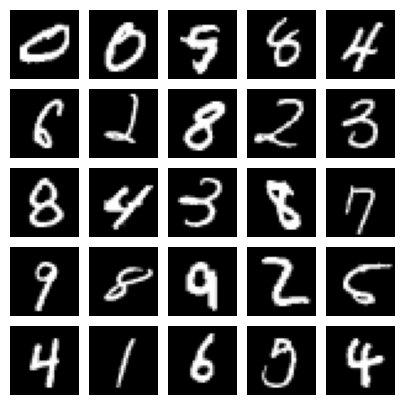

In [11]:
# get 25 sample training images for visualization
dataiter = iter(train_loader)
image = next(dataiter)

num_samples = 25
sample_images = [image[0][i,0] for i in range(num_samples)]

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

In [13]:
class Encoder(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=256):
        super(Encoder, self).__init__()

        # Note:
          # this is just a plain old fully conected-network with 2 hidden layers for feature extraction
          # but spits out two vectors - one for latent mean, one for log-variance

        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear (hidden_dim, latent_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)
        self.training = True

    def forward(self, x):
        x = self.LeakyReLU(self.linear1(x))
        x = self.LeakyReLU(self.linear2(x))

        mean = self.mean(x)
        log_var = self.var(x)
        return mean, log_var

In [14]:
class Decoder(nn.Module):

    def __init__(self, output_dim=784, hidden_dim=512, latent_dim=256):
        super(Decoder, self).__init__()

        # Note:
        # Go backwards through the encoder architecture --> scale it back up!
          # Doesn't have to exactly mirror, can be bigger/smaller/deeper/shallower, different architecture (CNN vs MLP)
          # Only requirement: encoder output size must watch decoder input size
        # Output layer depends on output:
          # no activation = regresion/linear output or for logits for later loss calculation
          # Sigmoid (oftend paired with BCE) --> probability/pixel intensity
          # softmax - multiclass classification --> paired with cross entropy closs
          # tan H - output in -1,1 for GANs
        self.linear2 = nn.Linear(latent_dim, hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.LeakyReLU(self.linear2(x))
        x = self.LeakyReLU(self.linear1(x))

        x_hat = torch.sigmoid(self.output(x)) # could also use BCE - depends on output
        return x_hat

In [16]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
            )

        # latent mean and variance
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
            )

    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        z = mean + var*epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, log_var

    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        x_hat = self.decode(z)
        return x_hat, mean, log_var

In [17]:
model = VAE().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)

In [18]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [19]:
def train(model, optimizer, epochs, device, x_dim=784):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))
    return overall_loss

In [20]:
train(model, optimizer, epochs=50, device=device)

	Epoch 1 	Average Loss:  181.71155514725064
	Epoch 2 	Average Loss:  162.28730411688753
	Epoch 3 	Average Loss:  157.16441451899
	Epoch 4 	Average Loss:  154.18484021220263
	Epoch 5 	Average Loss:  152.27853680287458
	Epoch 6 	Average Loss:  150.66240681083056
	Epoch 7 	Average Loss:  149.50062659771496
	Epoch 8 	Average Loss:  148.54265057648163
	Epoch 9 	Average Loss:  147.78350440838898
	Epoch 10 	Average Loss:  147.00728321616756
	Epoch 11 	Average Loss:  146.57197842758765
	Epoch 12 	Average Loss:  146.08354606309996
	Epoch 13 	Average Loss:  145.5593970256417
	Epoch 14 	Average Loss:  145.2318249980436
	Epoch 15 	Average Loss:  144.72715204051022
	Epoch 16 	Average Loss:  144.561547240192
	Epoch 17 	Average Loss:  144.06003971462854
	Epoch 18 	Average Loss:  143.83761508438545
	Epoch 19 	Average Loss:  143.5905591187135
	Epoch 20 	Average Loss:  143.34934840945849
	Epoch 21 	Average Loss:  142.92945780402232
	Epoch 22 	Average Loss:  143.03787562604342
	Epoch 23 	Average Loss:  1

8343722.0185546875

In [21]:
def generate_digit(mean, var):
    z_sample = torch.tensor([[mean, var]], dtype=torch.float).to(device)
    x_decoded = model.decode(z_sample)
    digit = x_decoded.detach().cpu().reshape(28, 28) # reshape vector to 2d array
    plt.title(f'[{mean},{var}]')
    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

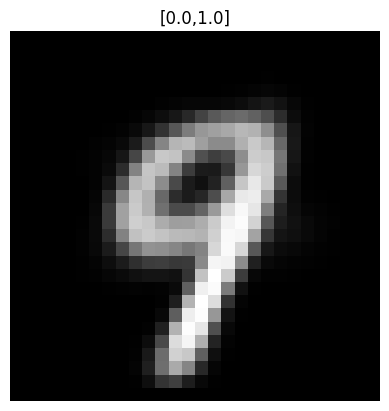

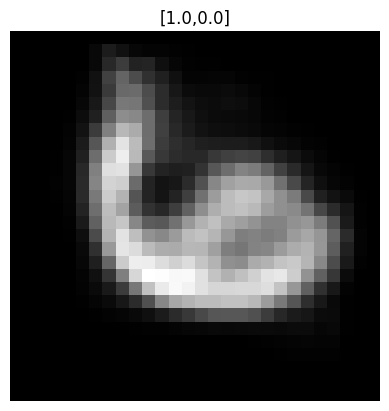

(None, None)

In [22]:
#img1: mean0, var1 / img2: mean1, var0
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

In [23]:
def plot_latent_space(model, scale=5.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

/tmp/ipython-input-2108995230.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit


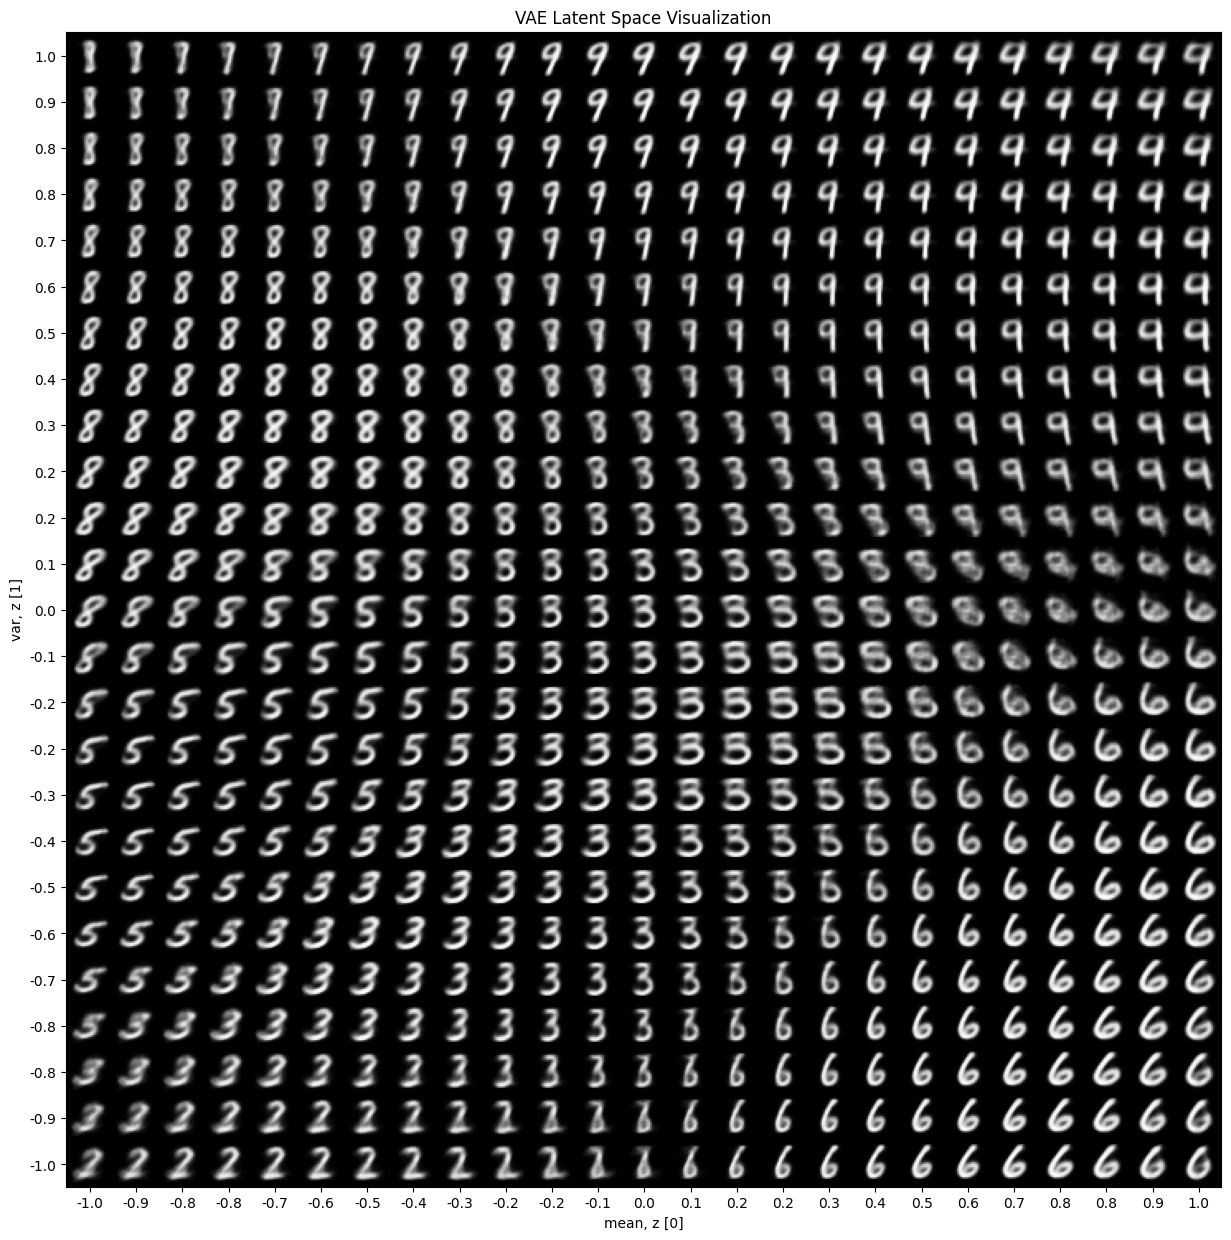

In [24]:
plot_latent_space(model, scale=1.0)

/tmp/ipython-input-2108995230.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit


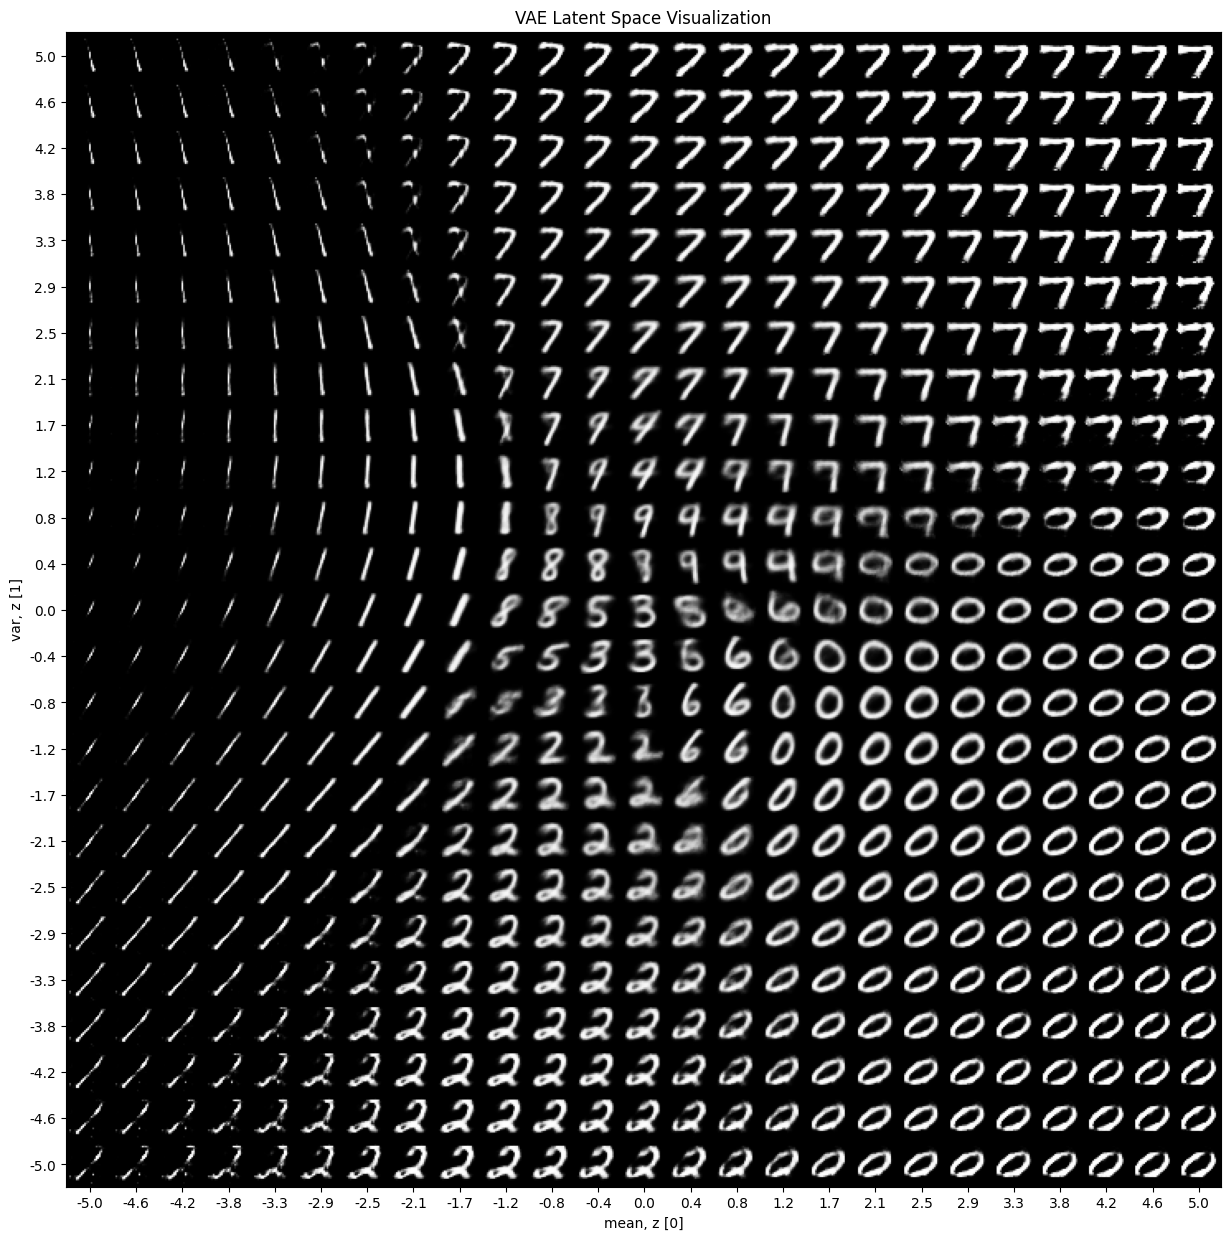

In [25]:
plot_latent_space(model, scale=5.0)